# HR Analytics - Employee Attrition Prediction

## Objective
Predict employee attrition and identify key drivers

<div style="
    height: 5px;
    background: linear-gradient(to right, #7b2ff7, #3f51f5, #2196f3);
    border-radius: 4px;
    margin: 1px 0;
"></div>

## Data Loading
---

In [ ]:

import pandas as pd


df_orginal = pd.read_csv("/kaggle/input/datasets/vikky11/hr-attrition-final-data/HR_Attrition_Final_Data.csv")

df=df_orginal.copy()

df.head()

## EDA
---

In [ ]:
#Checking for not-null values

df.info()


In [ ]:
#Breif Summary

df.describe()

In [58]:
# Checking Target Distribution and Class Imbalance

df["attrition"].value_counts()

attrition
No     1233
Yes     237
Name: count, dtype: int64

In [ ]:
# Checking for unique values

df["attrition"].unique()

## Data Preprocessing
---

In [63]:
#Mapping

df["attrition"] = df["attrition"].map({"Yes": 1, "No": 0})


In [64]:
df["attrition"].value_counts()

attrition
0    1233
1     237
Name: count, dtype: int64

In [ ]:
df = df.drop(columns=["employee_id"])

df

In [ ]:
X = df.drop("attrition", axis=1)
y = df["attrition"]


In [70]:
X = pd.get_dummies(X, drop_first=True)

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Building
###  1️⃣ Logistic Regression
---

In [82]:
from sklearn.linear_model import LogisticRegression

# Giving 'Yes' 4 times the importance of 'No'
model = LogisticRegression(class_weight={0: 1, 1: 4}, random_state=42)

model.fit(X_train, y_train)

LogisticRegression(class_weight={0: 1, 1: 4}, random_state=42)

In [84]:
y_pred = model.predict(X_test)


### Evaluation
---

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7380952380952381
Precision: 0.32558139534883723
Recall: 0.5957446808510638
F1 Score: 0.42105263157894735
Confusion Matrix:
 [[189  58]
 [ 19  28]]


### Feature Importance
---

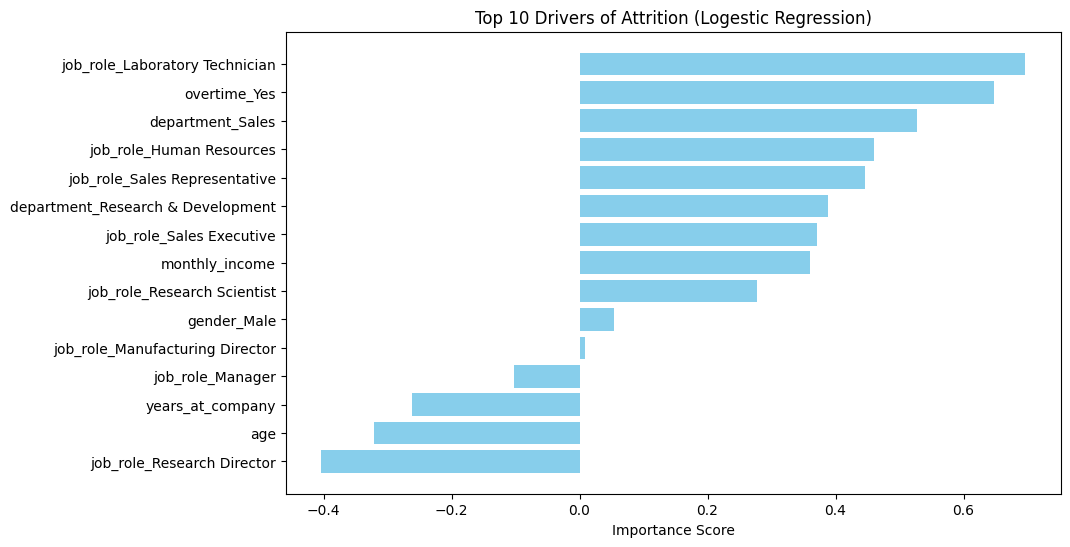

In [94]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Importance", ascending=False)

coefficients.head(10)
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Drivers of Attrition (Logestic Regression)')
plt.gca().invert_yaxis() 
plt.show()

### 2️⃣ Random Forest
---

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)

# Fit and Predict
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)



### Evaluation
---

In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test,  rf_preds))
print("Precision:", precision_score(y_test,  rf_preds))
print("Recall:", recall_score(y_test,  rf_preds))
print("F1 Score:", f1_score(y_test,  rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test,  rf_preds))

Accuracy: 0.8163265306122449
Precision: 0.3870967741935484
Recall: 0.2553191489361702
F1 Score: 0.3076923076923077
Confusion Matrix:
 [[228  19]
 [ 35  12]]


### Feature Importance
---

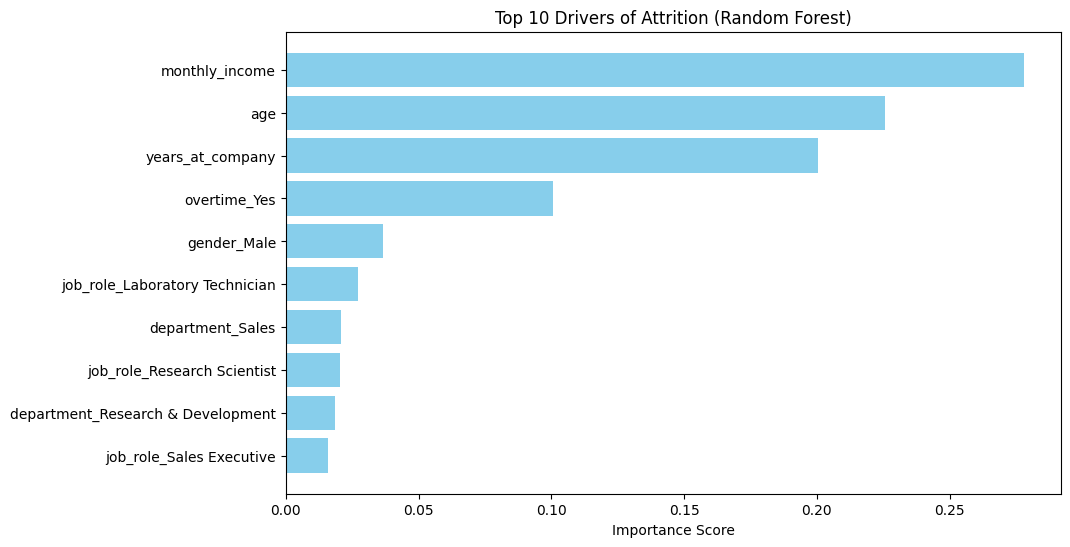

In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


importances = rf_model.feature_importances_
feature_names = X.columns 


feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Drivers of Attrition (Random Forest)')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

### 3️⃣ XGBoost
---

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


ratio = (y_train == 0).sum() / (y_train == 1).sum()


xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=ratio, # Critical for catching those who leave
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit and Predict
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)



### Evaluation
---

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test,  xgb_preds))
print("Precision:", precision_score(y_test,  xgb_preds))
print("Recall:", recall_score(y_test,  xgb_preds))
print("F1 Score:", f1_score(y_test, xgb_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test,  xgb_preds))

Accuracy: 0.7755102040816326
Precision: 0.3492063492063492
Recall: 0.46808510638297873
F1 Score: 0.4
Confusion Matrix:
 [[206  41]
 [ 25  22]]


### Feature Importance
---

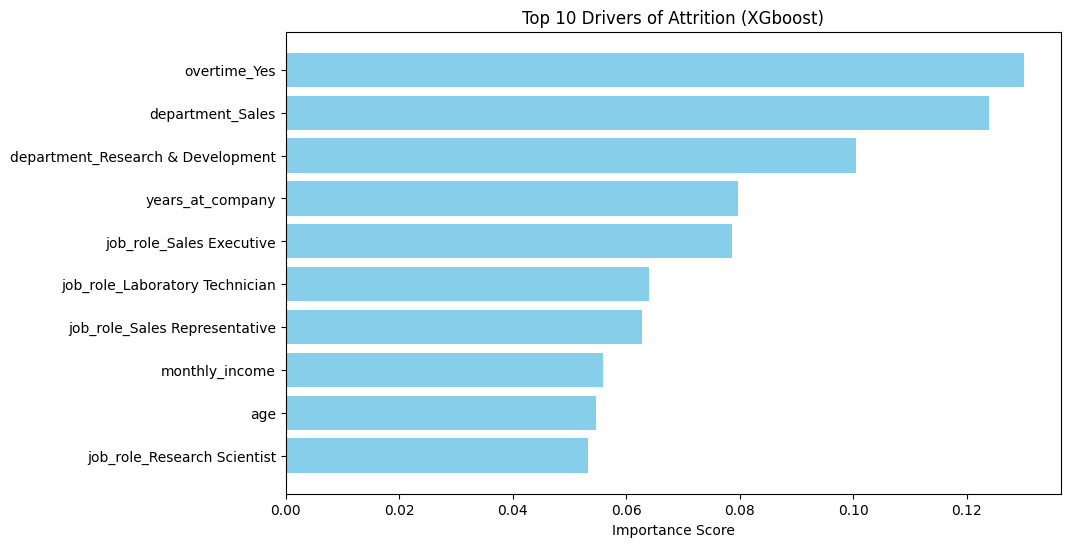

In [97]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


importances = xgb_model.feature_importances_
feature_names = X.columns 

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Drivers of Attrition (XGboost)')
plt.gca().invert_yaxis() 
plt.show()

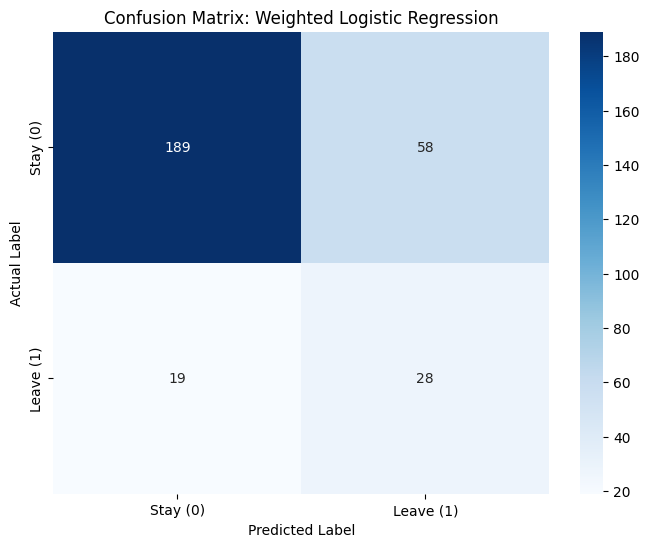

In [99]:
#confusion matrix for the winning model (Logistic Regression)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stay (0)', 'Leave (1)'], 
            yticklabels=['Stay (0)', 'Leave (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Weighted Logistic Regression')
plt.show()

### Visualizing Model Performance
---
The Heatmap above represents our final **Logistic Regression** model's performance on the test set. 

* **Top-Left (189):** Correctly predicted employees who stayed.
* **Bottom-Right (28):** Correctly identified employees at high risk of leaving (Our "Action List").
* **Bottom-Left (19):** Employees who left that the model missed.
* **Top-Right (58):** Employees predicted to leave who actually stayed (Potential "False Alarms").

By prioritizing **Recall**, we ensured that our "Action List" (Bottom-Right) is as large as possible, giving HR the best chance to intervene before a resignation occurs.



# Final Analysis: Employee Attrition Prediction


## 1. Model Performance Summary
We evaluated three different architectures to identify employees at risk of leaving (Attrition = 'Yes'). 

| Model | Accuracy | Precision | Recall (Capture Rate) | F1-Score |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression (Balanced)** | 73.8% | 32.5% | **59.6%** | **0.42** |
| **XGBoost (Weighted)** | 77.5% | 34.9% | 46.8% | 0.40 |
| **Random Forest** | **81.6%** | **38.7%** | 25.5% | 0.31 |

**Key Finding:** While Random Forest had the highest overall accuracy, **Logistic Regression with Balanced Weights** is the superior model for this business case. It successfully identified **~60% of all leavers**, providing the best balance between catching at-risk staff and managing false alarms.

---

## 2. Top Drivers of Attrition
Based on the feature importance and coefficients across our models, the following factors are the strongest predictors of an employee quitting:

1. **Job Role (Lab Technicians & Sales):** Specific roles show significantly higher turnover rates, suggesting department-specific culture or market pressure issues.
2. **Overtime:** Employees working overtime are among the most likely to leave, indicating a high correlation between burnout and attrition.
3. **Monthly Income & Age:** Younger employees and those with lower comparative salaries are at higher risk.
4. **Years at Company:** There is a "danger zone" in the early years of tenure where attrition is most frequent.

---

## 3. Strategic Recommendations for HR
To reduce the attrition rate, the following data-driven actions are recommended:

* **Targeted Retention Interviews:** Use the Logistic Regression model to flag "at-risk" employees in the Sales and Lab Tech departments for proactive stay-interviews.
* **Overtime Audit:** Review the workload of the departments with high overtime impact. Reducing mandatory extra hours could directly improve retention.
* **Compensation Benchmarking:** Re-evaluate the salary brackets for entry-level and mid-level roles, as income was a top-3 driver in our Random Forest analysis.
* **Early Career Support:** Implement mentorship programs for employees in their first 2–3 years, targeting the "Tenure" risk factor identified by the model.

<div style="
    height: 5px;
    background: linear-gradient(to right, #7b2ff7, #3f51f5, #2196f3);
    border-radius: 4px;
    margin: 1px 0;
"></div>